# Data storytelling notebook 2/2
Purpose: Tell the story of how explicit music changes over the globe during christmas.
Dataset: Using our `silver_spotify_daily`-table that spans from 2023/10-18 - 2025-06-11

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
# Konstanter
DB_PATH = "../data/music_warehouse.duckdb"

# Uppkoppling mot DB
con = duckdb.connect(DB_PATH)

## Prepare the data for storytelling.
- I've got data for day by day and to reduce my graph being "spiky" I will aggregate my my data and group it per week to get softer "waves" in my plot.

In [2]:
# Räkna ut procentandelen EXPLICIT vs CLEAN music per vecka
query_explicit = """
SELECT
    date_trunc('week', CAST(snapshot_date AS DATE)) AS week,
    -- Räkna andel Explicit i procent
    (COUNT(CASE WHEN is_explicit = true THEN 1 END) * 100.0 / COUNT(*)) AS explicit_pct,
    -- Räkna andel Clean i procent
    (COUNT(CASE WHEN is_explicit = false THEN 1 END) * 100.0 / COUNT(*)) AS clean_pct
FROM silver_spotify_daily
GROUP BY 1
ORDER BY 1
"""

df_explicit = con.execute(query_explicit).df()
con.close()

## Data is aggregated and grouped with my query above. Time to start building my plot.

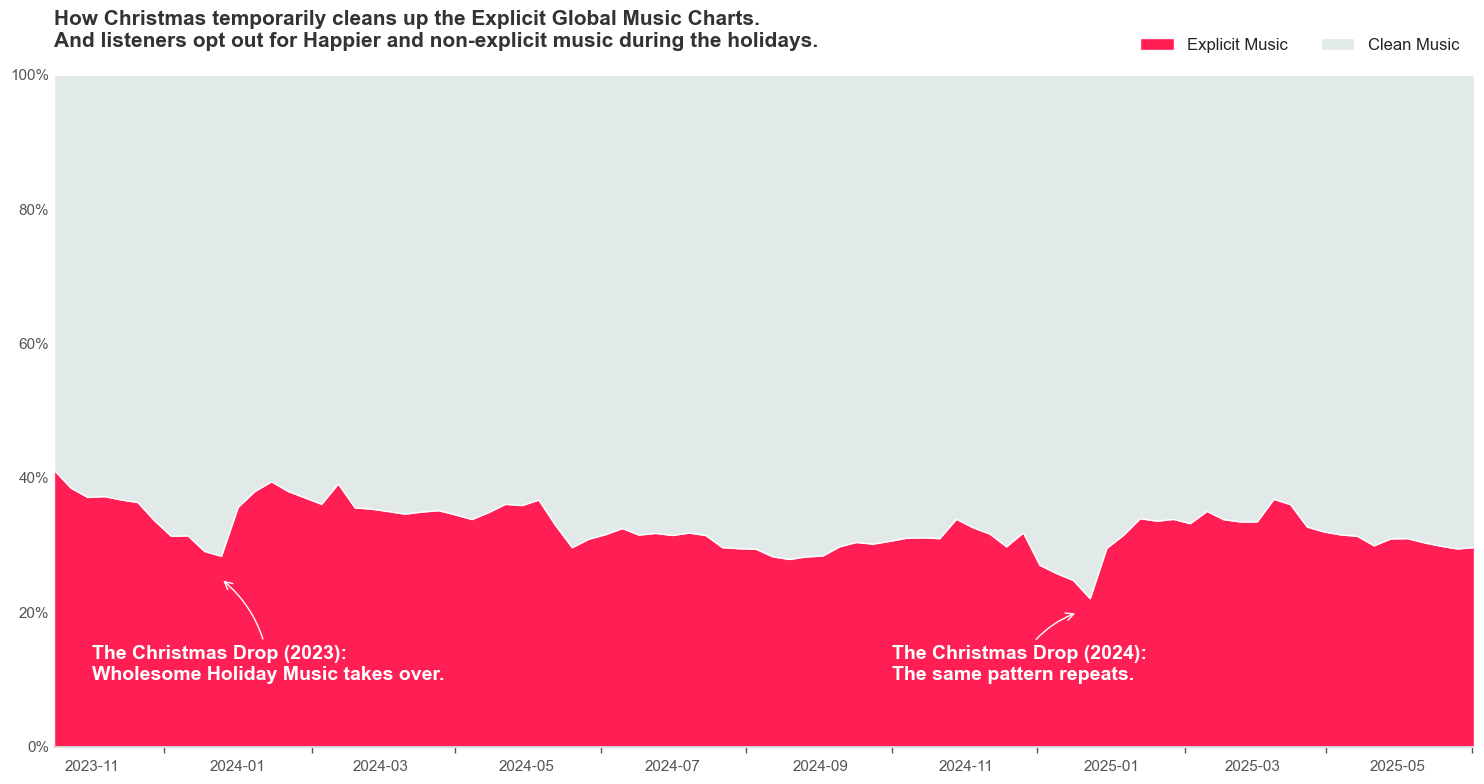

In [5]:
# 1) Förbered min data
df_plot = df_explicit.copy()
# Filtrera bort den allra sista ofullständiga veckan för finare graf
df_plot = df_plot.iloc[:-1]
df_plot['week'] = pd.to_datetime(df_plot['week'])

#2) "Grundinställningarna" i plotten.
sns.set_theme(style="white")
fix, ax = plt.subplots(figsize=(15,8))

# 3) Skapa min Stacked Area Chart. Stackplot tar in X-axis och sen en lista med mina Y värden som ska staplas
ax.stackplot(df_plot['week'],
             df_plot['explicit_pct'],
             df_plot['clean_pct'],
             labels=['Explicit Music', 'Clean Music'],
             colors=['#ff134b', '#e1e8e8'], # Ljusgrå för Clean, Mörkröd för Explicit
             alpha=0.95)                    # LITE transperens för mer clean view 

# 4) Decluttering (Spines etc)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Gömmer OCKSÅ vänster spine för ännu mer clean look
ax.spines['bottom'].set_color('#dddddd')

# 5) Formaterar Y-axis till PROCENT
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)}%"))
ax.set_ylim(0, 100) # LÅSER Y-axis mellan 0 och 100%
# Kapa "luften" på sidorna av X-axis
ax.set_xlim(df_plot['week'].min(), df_plot['week'].max())

# Format på X-axis med ÅR och minor TICKS för månader(För läsbarhet och mer förståeligt)
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.tick_params(axis='x', which='minor', bottom=True, colors='#555555', length=4, direction='out')
ax.tick_params(axis='both', which='major', colors='#555555', length=6)

# Tar bort alla fula streck på Y-axis men BEHÅLL alla siffror
ax.tick_params(axis='y', length=0, colors='#555555')

# ========================================
# 6) STORYTELLING ANNOTATIONS (X-MAX DIPS)
# Det är ett återkommande mönster, så jag
# markerar båda vintrarna datasettet har
# ========================================

# X-MAS 2023
x_xmas_23 = pd.to_datetime('2023-12-25')
plt.annotate(
    "The Christmas Drop (2023):\nWholesome Holiday Music takes over.",
    xy = (x_xmas_23, 25), # Pilen pekar ner i den röda ytan (där den dippar)
    xytext = (pd.to_datetime('2023-11-01'), 10),
    arrowprops = dict(facecolor = '#ffffff', edgecolor = '#ffffff', arrowstyle="->", connectionstyle="arc3,rad=0.2"),
    fontsize = 14, color = '#ffffff', fontweight= 'bold'
)

# X-MAS 2024
x_xmas_24 = pd.to_datetime('2024-12-18')
plt.annotate(
    "The Christmas Drop (2024):\nThe same pattern repeats.",
    xy = (x_xmas_24, 20), # Pilen pekar ner i den röda ytan (där den dippar)
    xytext= (pd.to_datetime('2024-10-01'), 10),
    arrowprops = dict(facecolor = '#ffffff', edgecolor = '#ffffff', arrowstyle="->", connectionstyle="arc3,rad=-0.2"),
    fontsize = 14, color = '#ffffff', fontweight = 'bold'
)
# ========================================
# ========================================

# 7) Legend och titel
# Fin legend placerad i top höger hörnet innuti grafen
ax.legend(loc = 'lower right', bbox_to_anchor=(1, 1.01), ncol=2, frameon = False, fontsize = 12)

plt.title("How Christmas temporarily cleans up the Explicit Global Music Charts.\nAnd listeners opt out for Happier and non-explicit music during the holidays.",
        fontsize = 15, fontweight = 'bold', color = '#333333', pad = 20, loc = 'left')

plt.xlabel("")

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("../data/plots/storytelling_graph_Christmas_explicit.png", dpi=300, bbox_inches='tight', facecolor='white')
